In [43]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv("../data/processed/brevo_import.csv")

df.head()
print(df.shape)

(968, 11)


In [45]:
features = [
    "COURSE",
    "SOURCE_TYPE",
    "SCHOLARSHIP"
]

X = df[features].copy()
X.head()

,COURSE,SOURCE_TYPE,SCHOLARSHIP
0,Business Intelligence (BI),CLUB,False
1,Business Intelligence (BI),CLUB,False
2,Business Intelligence (BI),CLUB,False
3,Business Intelligence (BI),CLUB,False
4,Business Intelligence (BI),CLUB,False


In [46]:
X.isnull().sum()

COURSE         0
SOURCE_TYPE    0
SCHOLARSHIP    0
dtype: int64

In [47]:
X_encoded = pd.get_dummies(
    df[features],
    columns=[
        "COURSE",
        "SOURCE_TYPE"
    ],
    dtype=int
)
X_encoded.head()

,SCHOLARSHIP,COURSE_AI Agent,COURSE_AI for work,COURSE_Business Analyst,COURSE_Business Intelligence (BI),COURSE_Data Analytics (DA),"COURSE_Data Analytics (DA), AI Agent",COURSE_Generative AI (GenAI),SOURCE_TYPE_CLUB,SOURCE_TYPE_OTHER,SOURCE_TYPE_SOCIAL,SOURCE_TYPE_UNIVERSITY
0,False,0,0,0,1,0,0,0,1,0,0,0
1,False,0,0,0,1,0,0,0,1,0,0,0
2,False,0,0,0,1,0,0,0,1,0,0,0
3,False,0,0,0,1,0,0,0,1,0,0,0
4,False,0,0,0,1,0,0,0,1,0,0,0


In [48]:
print(X_encoded.shape)

X_encoded.info()

(968, 12)
<class 'pandas.DataFrame'>
RangeIndex: 968 entries, 0 to 967
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   SCHOLARSHIP                           968 non-null    bool 
 1   COURSE_AI Agent                       968 non-null    int64
 2   COURSE_AI for work                    968 non-null    int64
 3   COURSE_Business Analyst               968 non-null    int64
 4   COURSE_Business Intelligence (BI)     968 non-null    int64
 5   COURSE_Data Analytics (DA)            968 non-null    int64
 6   COURSE_Data Analytics (DA), AI Agent  968 non-null    int64
 7   COURSE_Generative AI (GenAI)          968 non-null    int64
 8   SOURCE_TYPE_CLUB                      968 non-null    int64
 9   SOURCE_TYPE_OTHER                     968 non-null    int64
 10  SOURCE_TYPE_SOCIAL                    968 non-null    int64
 11  SOURCE_TYPE_UNIVERSITY                968 non-

In [49]:
X_encoded["SCHOLARSHIP"] = X_encoded["SCHOLARSHIP"].astype(int)
X_encoded.dtypes

SCHOLARSHIP                             int64
COURSE_AI Agent                         int64
COURSE_AI for work                      int64
COURSE_Business Analyst                 int64
COURSE_Business Intelligence (BI)       int64
COURSE_Data Analytics (DA)              int64
COURSE_Data Analytics (DA), AI Agent    int64
COURSE_Generative AI (GenAI)            int64
SOURCE_TYPE_CLUB                        int64
SOURCE_TYPE_OTHER                       int64
SOURCE_TYPE_SOCIAL                      int64
SOURCE_TYPE_UNIVERSITY                  int64
dtype: object

In [50]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)
print(type(X_scaled))
print(X_scaled.shape)

<class 'numpy.ndarray'>
(968, 12)


In [51]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

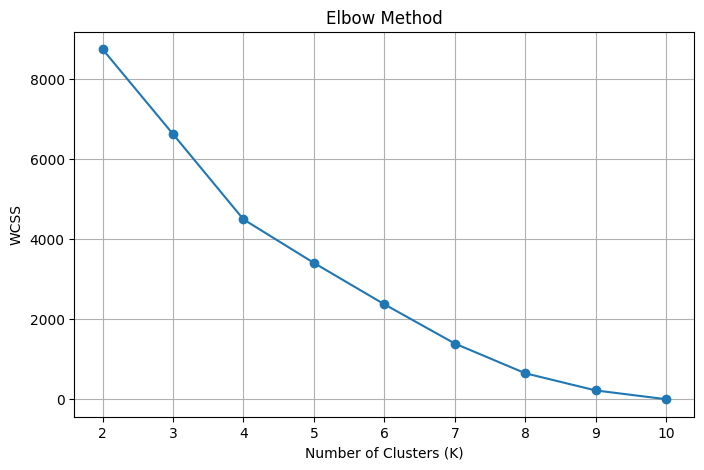

In [52]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [53]:
sil_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    sil_scores.append(score)

    print(f"K = {k}: {score:.4f}")

K = 2: 0.4503
K = 3: 0.5528
K = 4: 0.6597
K = 5: 0.7188
K = 6: 0.7593
K = 7: 0.7741
K = 8: 0.8460
K = 9: 0.9841
K = 10: 1.0000


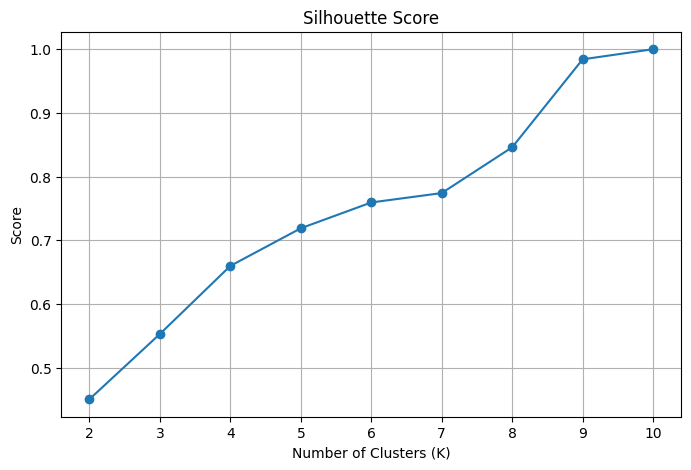

In [54]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), sil_scores, marker="o")

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")

plt.grid(True)

plt.show()

## Choosing the Optimal Number of Clusters (K)

Before training the KMeans model, it is necessary to determine an appropriate number of clusters (K).

### 1. Elbow Method

The Elbow Method evaluates the Within-Cluster Sum of Squares (WCSS) for different values of K.

- As K increases, WCSS always decreases because each cluster becomes smaller.
- The optimal K is typically located at the "elbow", where the reduction in WCSS begins to slow down significantly.
- In our experiment, the elbow appears around **K = 6–7**, indicating that increasing the number of clusters beyond this point provides diminishing returns.

### 2. Silhouette Score

The Silhouette Score measures how well-separated the clusters are.

- A score close to **1** indicates well-separated clusters.
- A score around **0** indicates overlapping clusters.
- Negative values indicate poor clustering.

Although the Silhouette Score continues to improve as K increases, choosing the highest score is not always the best decision because it may produce too many clusters for practical business use.

### 3. Business Considerations

The objective of this project is not only to maximize clustering performance but also to create meaningful customer segments for marketing automation in Brevo.

Choosing **K = 6** provides a good balance between:

- Sufficient cluster separation.
- Easy interpretation.
- Practical marketing segments.
- Manageable automation workflows and email campaigns.

Therefore, **K = 6** is selected for the final KMeans model.

In [55]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

df["CLUSTER"] = kmeans.fit_predict(X_scaled)
df["CLUSTER"].value_counts().sort_index()

CLUSTER
0    217
1    540
2    101
3     33
4     17
5     60
Name: count, dtype: int64

In [56]:
for i in range(6):
    print("="*60)
    print(f"Cluster {i}")

    display(
    df[df["CLUSTER"] == i][
        [
            "COURSE",
            "SOURCE_TYPE",
            "LEAD_SOURCE",  
            "SCHOLARSHIP"
        ]
    ].describe(include="all")
    )

Cluster 0


,COURSE,SOURCE_TYPE,LEAD_SOURCE,SCHOLARSHIP
count,217,217,217,217
unique,1,1,1,1
top,Generative AI (GenAI),UNIVERSITY,Lớp Công nghệ số của VNU,False
freq,217,217,217,217


Cluster 1


,COURSE,SOURCE_TYPE,LEAD_SOURCE,SCHOLARSHIP
count,540,540,540,540
unique,2,2,3,2
top,Business Intelligence (BI),CLUB,Sự kiện với các CLB,True
freq,537,442,257,355


Cluster 2


...

,COURSE,SOURCE_TYPE,LEAD_SOURCE,SCHOLARSHIP
count,33,33,33,33
unique,1,1,1,1
top,AI Agent,CLUB,Sự kiện với các CLB,True
freq,33,33,33,33


Cluster 4


,COURSE,SOURCE_TYPE,LEAD_SOURCE,SCHOLARSHIP
count,17,17,17,17
unique,1,1,1,1
top,AI for work,CLUB,Sự kiện với các CLB,True
freq,17,17,17,17


Cluster 5


,COURSE,SOURCE_TYPE,LEAD_SOURCE,SCHOLARSHIP
count,60,60,60,60
unique,1,1,2,1
top,Data Analytics (DA),OTHER,Sự kiện Data For Impact tháng 5/2026 tại HV Ng...,True
freq,60,60,49,60


## Cluster Interpretation

KMeans only assigns a numeric cluster ID (0–5). These IDs have no business meaning.

To use the clustering result in Brevo Marketing Automation, each cluster must be analyzed based on its dominant characteristics (Course, Lead Source, Lead Type, Scholarship).

After interpretation, each cluster will be assigned a meaningful business label that can be used for customer segmentation and automated marketing campaigns.

In [57]:
cluster_mapping = {
    0: "GENAI_VNU",
    1: "DA_SCHOLARSHIP",
    2: "BI_SCHOLARSHIP",
    3: "BI_CLUB_SCHOLARSHIP",
    4: "BA_FACEBOOK",
    5: "BI_AIESEC"
}
df["SEGMENT"] = df["CLUSTER"].map(cluster_mapping)
df[["CLUSTER","SEGMENT"]].head(20)

,CLUSTER,SEGMENT
0,1,DA_SCHOLARSHIP
1,1,DA_SCHOLARSHIP
2,1,DA_SCHOLARSHIP
3,1,DA_SCHOLARSHIP
4,1,DA_SCHOLARSHIP
5,1,DA_SCHOLARSHIP
6,1,DA_SCHOLARSHIP
7,1,DA_SCHOLARSHIP
8,1,DA_SCHOLARSHIP
9,1,DA_SCHOLARSHIP


In [58]:
df["SEGMENT"].value_counts()

SEGMENT
DA_SCHOLARSHIP         540
GENAI_VNU              217
BI_SCHOLARSHIP         101
BI_AIESEC               60
BI_CLUB_SCHOLARSHIP     33
BA_FACEBOOK             17
Name: count, dtype: int64

In [59]:
df.to_csv(
    "../data/processed/customer_segment.csv",
    index=False,
    encoding="utf-8-sig"
)

# Conclusion

The original lead dataset has been successfully segmented using the KMeans clustering algorithm.

Each cluster was manually interpreted and assigned a business-friendly segment name.

The generated file `customer_segment.csv` will be used in Day 3 to train a supervised classification model capable of predicting the segment of new incoming leads.

In [60]:
print(df["COURSE"].unique())

<StringArray>
[   'Business Intelligence (BI)',         'Generative AI (GenAI)',
              'Business Analyst',           'Data Analytics (DA)',
 'Data Analytics (DA), AI Agent',                   'AI for work',
                      'AI Agent']
Length: 7, dtype: str


In [61]:
import joblib

cols = joblib.load("../models/feature_columns.pkl")

print([c for c in cols if c.startswith("COURSE")])


['COURSE_AI Agent', 'COURSE_AI for work', 'COURSE_Business Analyst', 'COURSE_Business Intelligence (BI)', 'COURSE_Data Analytics (DA)', 'COURSE_Data Analytics (DA), AI Agent', 'COURSE_Generative AI (GenAI)']


In [62]:
print(df["SEGMENT"].value_counts())

SEGMENT
DA_SCHOLARSHIP         540
GENAI_VNU              217
BI_SCHOLARSHIP         101
BI_AIESEC               60
BI_CLUB_SCHOLARSHIP     33
BA_FACEBOOK             17
Name: count, dtype: int64


In [63]:
df.groupby("SEGMENT")["COURSE"].value_counts()

SEGMENT              COURSE                       
BA_FACEBOOK          AI for work                       17
BI_AIESEC            Data Analytics (DA)               60
BI_CLUB_SCHOLARSHIP  AI Agent                          33
BI_SCHOLARSHIP       Business Analyst                 101
DA_SCHOLARSHIP       Business Intelligence (BI)       537
                     Data Analytics (DA), AI Agent      3
GENAI_VNU            Generative AI (GenAI)            217
Name: count, dtype: int64

In [64]:
pd.crosstab(df["SEGMENT"], df["COURSE"])

COURSE,AI Agent,AI for work,Business Analyst,Business Intelligence (BI),Data Analytics (DA),"Data Analytics (DA), AI Agent",Generative AI (GenAI)
SEGMENT,,,,,,,
BA_FACEBOOK,0,17,0,0,0,0,0
BI_AIESEC,0,0,0,0,60,0,0
BI_CLUB_SCHOLARSHIP,33,0,0,0,0,0,0
BI_SCHOLARSHIP,0,0,101,0,0,0,0
DA_SCHOLARSHIP,0,0,0,537,0,3,0
GENAI_VNU,0,0,0,0,0,0,217


In [65]:
print(df["SOURCE_TYPE"].value_counts())

SOURCE_TYPE
CLUB          492
UNIVERSITY    315
SOCIAL         92
OTHER          69
Name: count, dtype: int64


In [66]:
pd.crosstab(df["CLUSTER"], df["COURSE"])

COURSE,AI Agent,AI for work,Business Analyst,Business Intelligence (BI),Data Analytics (DA),"Data Analytics (DA), AI Agent",Generative AI (GenAI)
CLUSTER,,,,,,,
0,0,0,0,0,0,0,217
1,0,0,0,537,0,3,0
2,0,0,101,0,0,0,0
3,33,0,0,0,0,0,0
4,0,17,0,0,0,0,0
5,0,0,0,0,60,0,0


In [ ]:
pd.crosstab(df["CLUSTER"], df["SOURCE_TYPE"])

SOURCE_TYPE,CLUB,OTHER,SOCIAL,UNIVERSITY
CLUSTER,,,,
0,0,0,0,217
1,442,0,0,98
2,0,9,92,0
3,33,0,0,0
4,17,0,0,0
5,0,60,0,0


: 